## Set Operations

In [1]:
setA = {1,2,3}
setB = {1,2,4,5}

print(setA)
print(setB)
print(setA.union(setB))     #union: A ∪ B
print(setA.intersection(setB)) #intersection: A ∩ B
print(setA.difference(setB)) #difference: A-B
print(setA.symmetric_difference(setB)) #symmetric difference: AΔB or (A ∪ B) − (A ∩ B)


{1, 2, 3}
{1, 2, 4, 5}
{1, 2, 3, 4, 5}
{1, 2}
{3}
{3, 4, 5}


Straight math-to-Python mapping: `union` = A ∪ B (everything in either), `intersection` = A ∩ B (only what's in both), `difference` = A − B (in A but not B - NOT symmetric, `setB.difference(setA)` gives a different answer), `symmetric_difference` = A △ B (in exactly one, never both). Python also lets you write these as operators instead of method calls: `-` for difference, `&` for intersection, `|` for union, `^` for symmetric difference - same result either way.

## Venn Diagram From Real Data

{1, 2, 3}
{1, 2, 4, 5}
{1, 2, 3, 4, 5}
{1, 2}
{3}
{3, 4, 5}


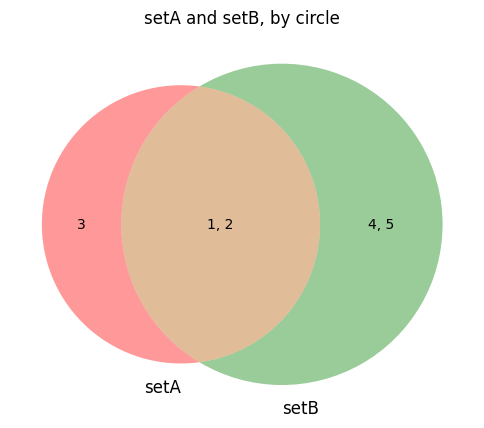

In [2]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

setA = {1, 2, 3}
setB = {1, 2, 4, 5}

print(setA)
print(setB)
print(setA.union(setB))                  # union: A U B
print(setA.intersection(setB))           # intersection: A n B
print(setA.difference(setB))             # difference: A - B
print(setA.symmetric_difference(setB))   # symmetric difference: A^B or (A U B) - (A n B)

# --- now draw it as a Venn diagram ---
only_A = setA - setB
only_B = setB - setA
both = setA & setB


fig, ax = plt.subplots(figsize=(6, 5))
v = venn2([setA, setB], set_labels=('setA', 'setB'), ax=ax)

v.get_label_by_id('10').set_text(', '.join(map(str, sorted(only_A))))
v.get_label_by_id('01').set_text(', '.join(map(str, sorted(only_B))))
v.get_label_by_id('11').set_text(', '.join(map(str, sorted(both))))

plt.title("setA and setB, by circle")
plt.savefig('../sets_full_demo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

`venn2` (from the separate `matplotlib_venn` library) draws the circles and figures out the overlap sizing automatically from the actual sets. By default each region just shows a *count*, so `get_label_by_id('10')`/`'01'`/`'11'` overwrites those with the real numbers instead - `'10'` = only in the first set, `'01'` = only in the second, `'11'` = in both.

## Venn Diagrams Per Operation

{1, 2, 3}
{1, 2, 4, 5}
{1, 2, 3, 4, 5}
{1, 2}
{3}
{3, 4, 5}


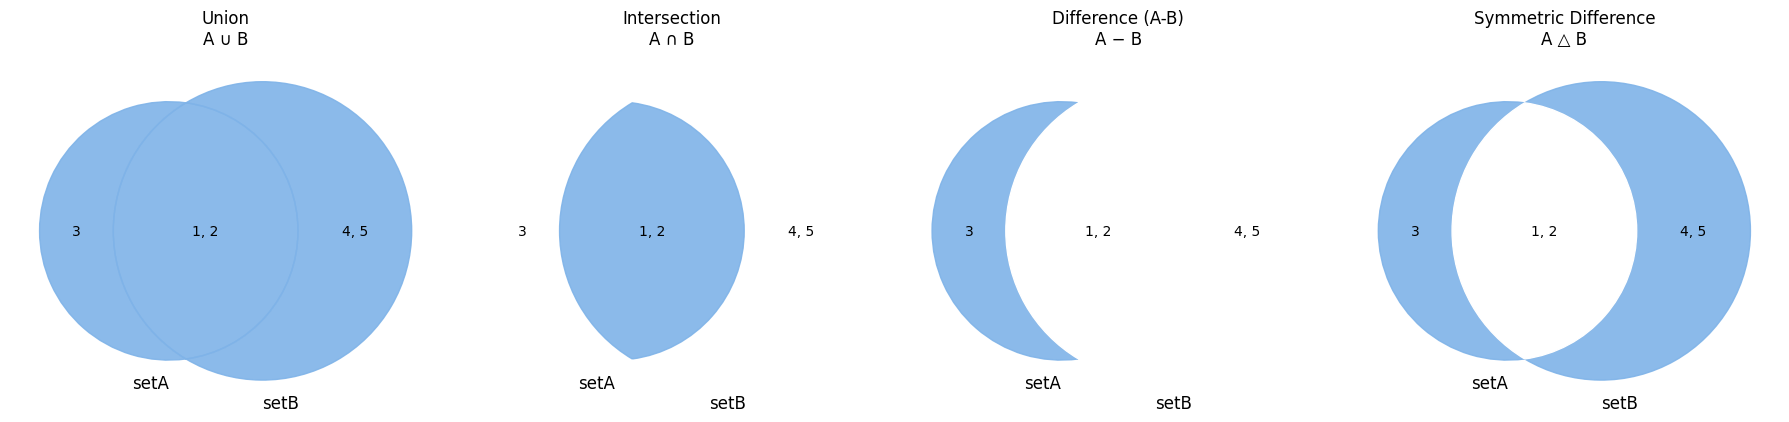

In [3]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

setA = {1, 2, 3}
setB = {1, 2, 4, 5}

print(setA)
print(setB)
print(setA.union(setB))                  # union: A U B
print(setA.intersection(setB))           # intersection: A n B
print(setA.difference(setB))             # difference: A - B
print(setA.symmetric_difference(setB))   # symmetric difference: A^B or (A U B) - (A n B)

only_A = setA - setB
only_B = setB - setA
both = setA & setB

# each entry: title, notation, which regions get colored ('10'=only A, '01'=only B, '11'=overlap)
operations = [
    ("Union", "A ∪ B", {'10', '01', '11'}),
    ("Intersection", "A ∩ B", {'11'}),
    ("Difference (A-B)", "A − B", {'10'}),
    ("Symmetric Difference", "A △ B", {'10', '01'}),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (title, notation, highlighted) in zip(axes, operations):
    v = venn2([setA, setB], set_labels=('setA', 'setB'), ax=ax)

    # label every region with its real numbers, not a count
    v.get_label_by_id('10').set_text(', '.join(map(str, sorted(only_A))))
    v.get_label_by_id('01').set_text(', '.join(map(str, sorted(only_B))))
    v.get_label_by_id('11').set_text(', '.join(map(str, sorted(both))))

    # color only the region(s) relevant to this operation; fade the rest to white
    for region_id in ('10', '01', '11'):
        patch = v.get_patch_by_id(region_id)
        if patch is None:
            continue
        if region_id in highlighted:
            patch.set_color('#7FB3E8')
            patch.set_alpha(0.9)
        else:
            patch.set_color('white')
            patch.set_alpha(1)

    ax.set_title(f"{title}\n{notation}", fontsize=12)

plt.tight_layout()
plt.savefig('../sets_operations_venn.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Same `venn2` drawing, done four times in a loop - one per operation - but now `get_patch_by_id(region_id)` grabs the actual circle-segment shape and recolors it: blue if that region belongs to the current operation, white if not. That's the "shaded Venn diagram" picture turned into real code instead of hand-drawn shapes.

## Set Relationships: Subset and Superset

small <= big   (subset?)        -> True
small <  big   (PROPER subset?) -> True
big   >= small (superset?)      -> True
small.issubset(big)             -> True


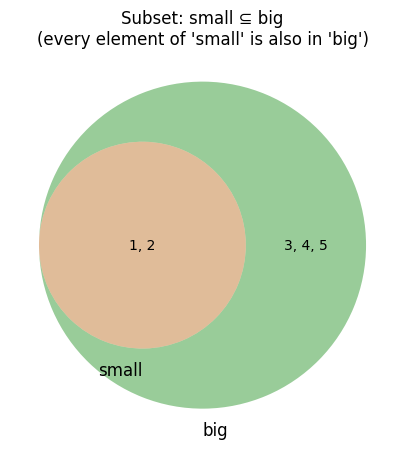

In [4]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

small = {1, 2}
big = {1, 2, 3, 4, 5}

print("small <= big   (subset?)        ->", small <= big)
print("small <  big   (PROPER subset?) ->", small < big)      # proper = smaller, can't be equal
print("big   >= small (superset?)      ->", big >= small)
print("small.issubset(big)             ->", small.issubset(big))   # same check, spelled out

fig, ax = plt.subplots(figsize=(5, 5))
v = venn2([small, big], set_labels=('small', 'big'), ax=ax)

only_small = small - big     # empty - EVERY element of small is also in big
only_big = big - small
overlap = small & big

v.get_label_by_id('10').set_text('')     # nothing here - that's the whole point of a subset
v.get_label_by_id('01').set_text(', '.join(map(str, sorted(only_big))))
v.get_label_by_id('11').set_text(', '.join(map(str, sorted(overlap))))

ax.set_title("Subset: small ⊆ big\n(every element of 'small' is also in 'big')")
plt.show()

Notice `venn2` draws this completely differently from the earlier four
operations - it computes circle sizes from the *actual* set contents, and since `small - big` is
empty, the "only small" sliver has nowhere to go: the `small` circle collapses entirely **inside**
`big`. That picture - one circle fully swallowed by the other - is what a subset relationship looks
like.

Subset (`<=`) vs. proper subset (`<`): a set is always a subset of itself (`{1,2} <= {1,2}` is
`True`), but never a *proper* subset of itself (`{1,2} < {1,2}` is `False` - proper subset demands
it be strictly smaller). And superset is just the same relationship, described from the other
direction: saying `big >= small` is exactly the same fact as `small <= big`, just read right-to-left
instead of left-to-right - same picture answers both questions.

## Set Relationships: Disjoint Sets

a.isdisjoint(b)      -> True
a & b (intersection) -> set()


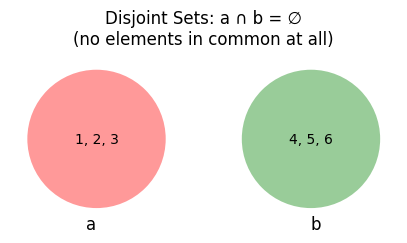

In [5]:
a = {1, 2, 3}
b = {4, 5, 6}

print("a.isdisjoint(b)      ->", a.isdisjoint(b))
print("a & b (intersection) ->", a & b)

fig, ax = plt.subplots(figsize=(5, 5))
v = venn2([a, b], set_labels=('a', 'b'), ax=ax)

v.get_label_by_id('10').set_text(', '.join(map(str, sorted(a))))
v.get_label_by_id('01').set_text(', '.join(map(str, sorted(b))))
# no '11' region to label at all - when two sets share NOTHING, matplotlib_venn doesn't
# even draw an overlap patch for it

ax.set_title("Disjoint Sets: a ∩ b = ∅\n(no elements in common at all)")
plt.show()

This is the one case where the two circles don't touch - `venn2` only
overlaps circles when the sets actually share elements, and here `a & b` is empty, so there's
nothing to overlap. Sets like this are called **disjoint**, and it's worth knowing there's a direct
method for checking it (`a.isdisjoint(b)`) rather than writing `len(a & b) == 0` yourself every
time.

## Set Relationships: Complement (Relative to a Universal Set)

U                        -> {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
A                        -> {8, 2, 4, 6}
complement of A (U - A)  -> {1, 3, 5, 7, 9, 10}


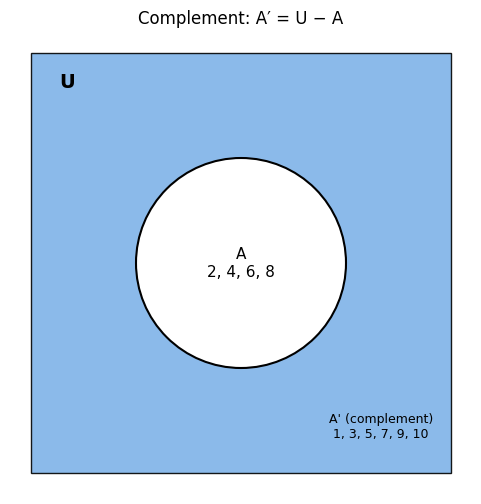

In [6]:
import matplotlib.patches as patches

U = set(range(1, 11))      # the "universal set" - everything we've agreed to consider: 1-10
A = {2, 4, 6, 8}

complement_A = U - A       # everything in U that is NOT in A

print("U                        ->", U)
print("A                        ->", A)
print("complement of A (U - A)  ->", complement_A)

fig, ax = plt.subplots(figsize=(6, 6))

# U is drawn as the WHOLE rectangle - there's no "outside" of the universal set
rect = patches.Rectangle((-3, -3), 6, 6, facecolor='#7FB3E8', alpha=0.9, edgecolor='black')
ax.add_patch(rect)

# A is a white circle cut out of it - whatever's left colored IS the complement
circle = patches.Circle((0, 0), 1.5, facecolor='white', edgecolor='black', linewidth=1.5)
ax.add_patch(circle)

ax.text(0, 0, "A\n" + ', '.join(map(str, sorted(A))), ha='center', va='center', fontsize=11)
ax.text(-2.6, 2.5, "U", fontsize=14, fontweight='bold')
ax.text(2.0, -2.5, "A' (complement)\n" + ', '.join(map(str, sorted(complement_A))),
        ha='center', fontsize=9)

ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Complement: A′ = U − A")
plt.show()

The complement doesn't fit the two-circle `venn2` picture at all, because it
needs something the other operations don't: a **universal set** `U` - the full pool of "everything
we're considering" (here, just the numbers 1 through 10). `A′` (read "A complement") is simply
*everything in U that isn't in A*, which is why the code is just one line: `U - A` - the exact same
`-` operator as the ordinary difference from before, just with the universal set standing in for
the left-hand side.

That's also why the drawing looks different: instead of two circles, it's a rectangle (`U`, the
whole space) with a hole cut out for `A` - and the blue that's left over, everywhere outside that
hole, *is* the complement.

## List Intersection

In [7]:
l1 = [11, 5, 13, 21, 2, 3, 18, 4, 12, 19]
l2 = [2, 17, 7, 29, 3, 14, 24, 25, 8, 22]
def getIntersection(l1,l2):
    intersection =set()
    for x in l2:
        if x in l1:
            intersection.add(x)
    return intersection
print(getIntersection(l1,l2))


{2, 3}


`intersection.add(x)` is the set equivalent of `.append()` on a list. Worth noticing: `if x in l1` checks membership in a plain **list**, which scans element-by-element every time - the earlier `get_intersection` version from the set-operations exercises converted the second list into a `set` first specifically to make that check instant instead of a scan. Doesn't matter for ten-element lists like these, but it would for large ones.

## First Non-Duplicate Character

In [8]:
def first_non_duplicate(s):
    # Step 1: count how many times each character appears (same blueprint as `frequency`)
    counts = {} # this is a map!
    for ch in s:
        if ch not in counts:
            counts[ch] = 1
        else:
            counts[ch] += 1

    # Step 2: walk through the string again, IN ORDER, and return the first
    # character whose count is exactly 1
    for ch in s:
        if counts[ch] == 1:
            return ch

    return None   # nothing had a count of 1

print(first_non_duplicate("stress")) #Output: 't'
print(first_non_duplicate("swiss")) #Output: 'w'
print(first_non_duplicate("aabbcc")) #Output: 'none'
print(first_non_duplicate("abcabcde")) #Output: 'd'


t
w
None
d


Same counting blueprint as `frequency` (`counts` is a dict/map - build it in one pass), then a **second** pass walks the string again in its original order and returns the first character whose count is exactly 1. Needs two passes because on the first one you can't yet know whether a character will repeat later - trace `"swiss"` by hand: `counts` ends up `{s: 3, w: 1, i: 1}`, and the second pass hits `w` before `i`, so `w` wins even though both are technically unique.

## Exercise 5a: Hash Table with Separate Chaining

In [9]:
class HashTableChaining:
    """Each slot holds a small list (a "bucket") instead of a single value - when two keys
    collide, they just both live in that slot's list."""

    def __init__(self, size=10):
        self.size = size
        self.buckets = [[] for _ in range(self.size)]   # one empty bucket per slot

    def _hash(self, key):
        """The lecture's string hash: every letter contributes, scaled by powers of 31,
        computed incrementally (Horner's method) instead of with **."""
        hash_value = 0
        for ch in str(key):
            hash_value = hash_value * 31 + ord(ch)
        return hash_value % self.size

    def put(self, key, value):
        index = self._hash(key)
        bucket = self.buckets[index]
        for i, (k, v) in enumerate(bucket):
            if k == key:
                bucket[i] = (key, value)     # key already there -> overwrite
                print(f"put({key!r}, {value}) -> slot {index}, key already there, updated")
                return
        bucket.append((key, value))          # new key -> add to this slot's bucket
        if len(bucket) == 1:
            print(f"put({key!r}, {value}) -> slot {index} (empty, no collision)")
        else:
            print(f"put({key!r}, {value}) -> slot {index}, COLLISION - now {len(bucket)} items share this slot")

    def get(self, key):
        bucket = self.buckets[self._hash(key)]
        for k, v in bucket:
            if k == key:
                return v
        raise KeyError(key)

    def delete(self, key):
        bucket = self.buckets[self._hash(key)]
        for i, (k, v) in enumerate(bucket):
            if k == key:
                del bucket[i]
                return
        raise KeyError(key)

    def __contains__(self, key):
        return any(k == key for k, v in self.buckets[self._hash(key)])

`_hash` is the lecture's string-hashing formula (`Hash Tom = 84*31² + 111*31
+ 109 = 84274`), computed the efficient way: `hash_value * 31 + ord(ch)` builds up the same total
one letter at a time instead of raising 31 to a fresh power every time (this shortcut is called
Horner's method).

The key idea of **separate chaining**: each slot in `self.buckets` isn't a single value, it's a
small list. When two keys land on the same slot, they don't fight over it - they just both sit in
that slot's list. `put`, `get`, and `delete` all work the same way: hash the key to find *which*
bucket, then do a short scan *inside just that one bucket* for the exact entry.

In [10]:
table = HashTableChaining(size=5)
for name, age in [("Tom", 84), ("Dick", 71), ("Harry", 65), ("Sam", 40), ("Pete", 33)]:
    table.put(name, age)

for i, bucket in enumerate(table.buckets):
    print(f"slot {i}: {bucket}")

put('Tom', 84) -> slot 4 (empty, no collision)
put('Dick', 71) -> slot 4, COLLISION - now 2 items share this slot
put('Harry', 65) -> slot 3 (empty, no collision)
put('Sam', 40) -> slot 4, COLLISION - now 3 items share this slot
put('Pete', 33) -> slot 3, COLLISION - now 2 items share this slot
slot 0: []
slot 1: []
slot 2: []
slot 3: [('Harry', 65), ('Pete', 33)]
slot 4: [('Tom', 84), ('Dick', 71), ('Sam', 40)]


`Tom`, `Dick`, and `Sam` all hash to **slot 4** (each hash `% 5` leaves
remainder 4), and `Harry`/`Pete` both land in **slot 3** - real collisions, from real hash values.
With chaining, that's no problem at all: they just pile up together in that slot's list.

In [11]:
print("Sam" in table, "->", table.get("Sam"))

table.delete("Dick")
print("Dick" in table)
print("slot 4 after deleting Dick:", table.buckets[4])

True -> 40
False
slot 4 after deleting Dick: [('Tom', 84), ('Sam', 40)]


Deleting `"Dick"` only removes *that one entry* - `"Tom"` and `"Sam"` are
still sitting in slot 4's list afterward, untouched. That's the advantage chaining has for deletion:
you're just removing an item from an ordinary list, nothing more.

## Exercise 5b: Hash Table with Linear Probing

In [12]:
class HashTableLinearProbing:
    """Open addressing: every key lives directly IN the array itself - no buckets. A collision
    is resolved by walking forward, one slot at a time, until an empty spot is found."""

    def __init__(self, size=10):
        self.size = size
        self.slots = [None] * self.size   # None means "this slot is empty"

    def _hash(self, key):
        hash_value = 0
        for ch in str(key):
            hash_value = hash_value * 31 + ord(ch)
        return hash_value % self.size

    def put(self, key, value):
        start = self._hash(key)
        index = start
        probes = 0
        for _ in range(self.size):             # never probe more than `size` times
            if self.slots[index] is None or self.slots[index][0] == key:
                self.slots[index] = (key, value)
                if probes == 0:
                    print(f"put({key!r}, {value}) -> hashes to slot {start}, empty, placed directly")
                else:
                    print(f"put({key!r}, {value}) -> hashes to slot {start}, occupied - "
                          f"probed forward {probes} time(s) -> placed at slot {index}")
                return
            index = (index + 1) % self.size    # LINEAR probing: always move exactly 1 slot
            probes += 1
        raise Exception("hash table is full")

    def get(self, key):
        index = self._hash(key)
        for _ in range(self.size):
            if self.slots[index] is None:
                raise KeyError(key)            # hit empty slot -> key was never inserted
            if self.slots[index][0] == key:
                return self.slots[index][1]
            index = (index + 1) % self.size
        raise KeyError(key)

Same `_hash` function as before, but a completely different way of
resolving a collision: instead of a list per slot, `put` just tries the next slot (`index + 1`,
wrapping back to `0` with `% self.size`) over and over until it finds one that's empty. `get` does
the same walk - if it lands on `None` before finding the key, the key was never there.

The `for _ in range(self.size)` guard matters: it's the lecture's "stop after probing N slots"
rule, so a full table raises a clear error instead of looping forever.

In [13]:
table = HashTableLinearProbing(size=5)
for name, age in [("Tom", 84), ("Dick", 71), ("Harry", 65), ("Sam", 40), ("Pete", 33)]:
    table.put(name, age)

for i, slot in enumerate(table.slots):
    print(f"slot {i}: {slot}")

put('Tom', 84) -> hashes to slot 4, empty, placed directly
put('Dick', 71) -> hashes to slot 4, occupied - probed forward 1 time(s) -> placed at slot 0
put('Harry', 65) -> hashes to slot 3, empty, placed directly
put('Sam', 40) -> hashes to slot 4, occupied - probed forward 2 time(s) -> placed at slot 1
put('Pete', 33) -> hashes to slot 3, occupied - probed forward 4 time(s) -> placed at slot 2
slot 0: ('Dick', 71)
slot 1: ('Sam', 40)
slot 2: ('Pete', 33)
slot 3: ('Harry', 65)
slot 4: ('Tom', 84)


This reproduces the lecture's own "Hash Table Example" slide exactly:
`Tom` hashes straight to slot 4, `Dick` also hashes to 4 but that's taken so it wraps around to
slot 0, `Harry` gets slot 3 directly, `Sam` hashes to 4 and has to probe all the way to slot 1, and
`Pete` hashes to 3 and probes to slot 2. Five names into a table of size 5 fills it **completely** -
exactly the slide's own warning that "many lookups will probe a lot!" when the table gets full.

In [14]:
print("Sam ->", table.get("Sam"))
print("Pete ->", table.get("Pete"))

try:
    table.put("Ann", 25)
except Exception as e:
    print("inserting a 6th name failed:", e)

Sam -> 40
Pete -> 33
inserting a 6th name failed: hash table is full


With the table completely full, there's nowhere left for a 6th name to go -
`put` probes all 5 slots, never finds an empty one, and raises. This is exactly why the lecture's
"Reducing Collisions By Growing: Rehashing" slide exists: a real hash table doubles its size and
reinserts everything once it gets too full, long before it's completely packed like this.

## Exercise 5c: Hash Table with Quadratic Probing

In [15]:
class HashTableQuadraticProbing:
    """Same idea as linear probing, but the probe DISTANCE grows (1, 4, 9, 16, ...) instead of
    always moving just one slot - this spreads collisions out instead of forming long clusters."""

    def __init__(self, size=10):
        self.size = size
        self.slots = [None] * self.size

    def _hash(self, key):
        hash_value = 0
        for ch in str(key):
            hash_value = hash_value * 31 + ord(ch)
        return hash_value % self.size

    def put(self, key, value):
        start = self._hash(key)
        for i in range(self.size):
            index = (start + i * i) % self.size    # QUADRATIC: i^2 instead of just i
            if self.slots[index] is None or self.slots[index][0] == key:
                self.slots[index] = (key, value)
                if i == 0:
                    print(f"put({key!r}, {value}) -> hashes to slot {start}, empty, placed directly")
                else:
                    print(f"put({key!r}, {value}) -> hashes to slot {start}, occupied - "
                          f"tried offset +{i * i} -> placed at slot {index}")
                return
        raise Exception("hash table is full (or this probe sequence can't reach every slot)")

    def get(self, key):
        start = self._hash(key)
        for i in range(self.size):
            index = (start + i * i) % self.size
            if self.slots[index] is None:
                raise KeyError(key)
            if self.slots[index][0] == key:
                return self.slots[index][1]
        raise KeyError(key)

Only one line really changed from linear probing: `index = (start + i*i) %
self.size` instead of just moving forward by 1 each time. This is exactly the lecture's "Generating
the quadratic sequence" trick - the probe sequence from a starting point `s` is `s, s+1, s+4, s+9,
s+16, ...` (all taken `% size`).

Why bother? Linear probing tends to form long *clusters* of occupied slots (the lecture calls this
out directly) - once a run of slots fills up, every new collision nearby has to wade through the
whole cluster. Growing the probe distance spreads collisions out across the table instead.

One caveat straight from the slides: "probe sequence may not produce all table slots" - quadratic
probing can fail to reach some slots for certain table sizes, which is why real implementations are
careful about picking sizes (often a prime number) that avoid this.

In [16]:
table = HashTableQuadraticProbing(size=7)
for name, age in [("Tom", 84), ("Dick", 71), ("Harry", 65), ("Sam", 40), ("Pete", 33)]:
    table.put(name, age)

for i, slot in enumerate(table.slots):
    print(f"slot {i}: {slot}")

put('Tom', 84) -> hashes to slot 1, empty, placed directly
put('Dick', 71) -> hashes to slot 0, empty, placed directly
put('Harry', 65) -> hashes to slot 0, occupied - tried offset +4 -> placed at slot 4
put('Sam', 40) -> hashes to slot 6, empty, placed directly
put('Pete', 33) -> hashes to slot 4, occupied - tried offset +1 -> placed at slot 5
slot 0: ('Dick', 71)
slot 1: ('Tom', 84)
slot 2: None
slot 3: None
slot 4: ('Harry', 65)
slot 5: ('Pete', 33)
slot 6: ('Sam', 40)


Note the table size changed to 7 here - with only 5 slots, quadratic
probing's own offsets (`0, 1, 4, 9%5=4, 16%5=1, ...`) actually repeat before reaching every slot,
which is a live example of the "may not produce all table slots" caveat above. Size 7 gives the
probe sequence enough room to spread out, and all five names land without any `put` running out of
slots to try.